<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab4/mldl_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Preprocessing
df = pd.read_csv('adult.csv').replace('?', pd.NA).dropna()
le = LabelEncoder()
for col in ['workclass', 'education', 'marital-status', 'occupation', 'gender']:
    df[col] = le.fit_transform(df[col])

X = df[['age', 'workclass', 'educational-num', 'marital-status', 'occupation', 'gender', 'hours-per-week']]
y = df['income'].map({'<=50K': 0, '>50K': 1})

# 2. Split and Scale (CRITICAL for KNN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 4. Results
print(classification_report(y_test, knn.predict(X_test)))
print(f"ROC AUC: {roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]):.4f}")

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      6842
           1       0.63      0.58      0.60      2203

    accuracy                           0.82      9045
   macro avg       0.75      0.74      0.74      9045
weighted avg       0.81      0.82      0.81      9045

ROC AUC: 0.8370


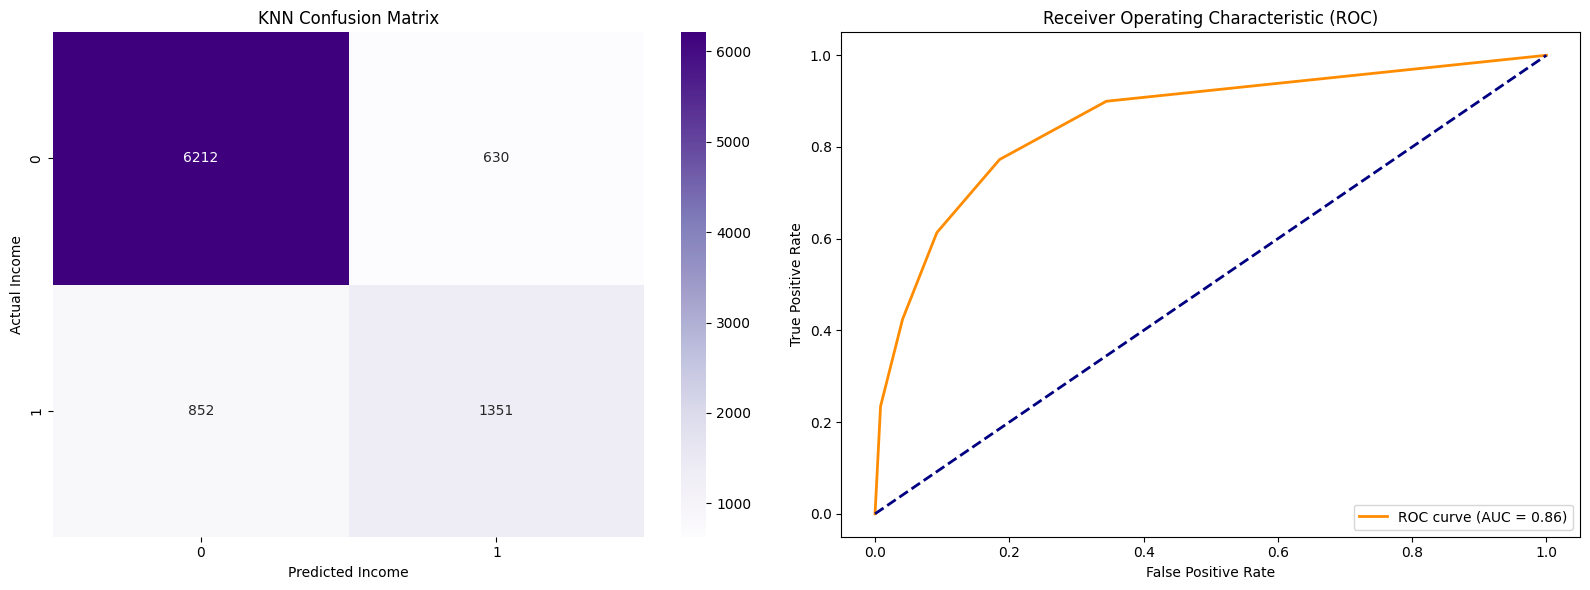

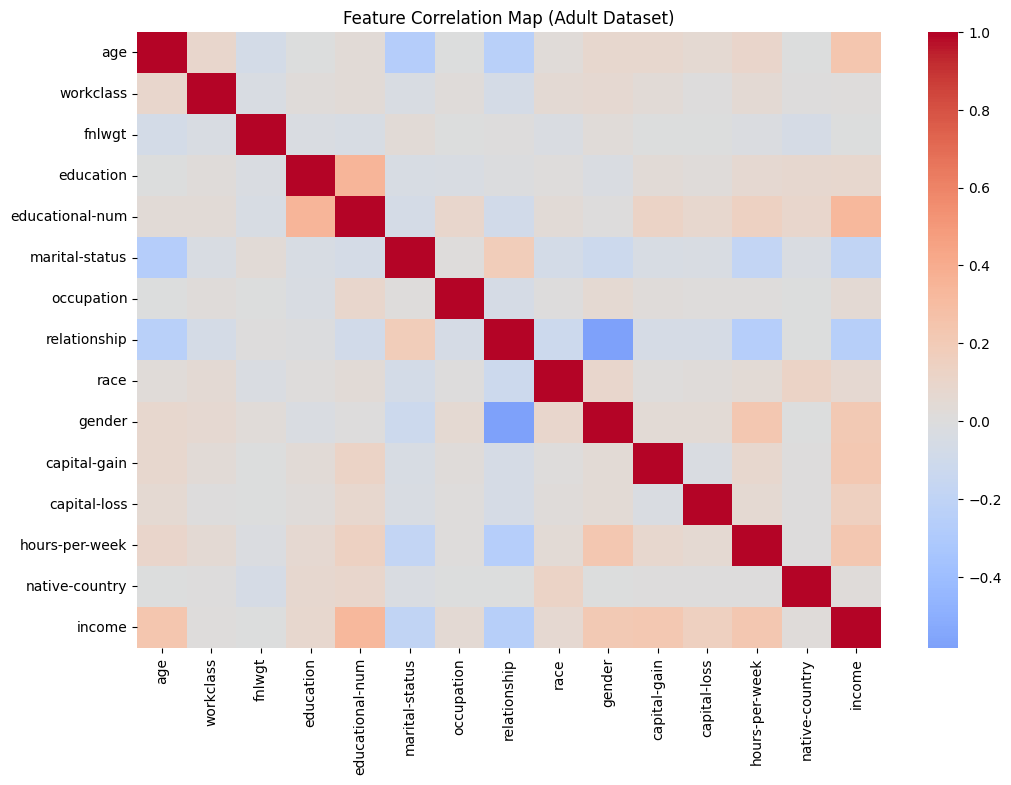

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6842
           1       0.68      0.61      0.65      2203

    accuracy                           0.84      9045
   macro avg       0.78      0.76      0.77      9045
weighted avg       0.83      0.84      0.83      9045



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# 1. Load and Clean Data
df = pd.read_csv('adult.csv')
df = df.replace('?', np.nan).dropna() # Remove missing values

# 2. Preprocessing
# Encode categorical features
le = LabelEncoder()
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Convert 'income' column to numerical values for correlation calculation and model training
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# Prepare X and y
X = df.drop(['income', 'fnlwgt'], axis=1) # fnlwgt is usually dropped in this dataset
y = df['income']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- IMPORTANT: Scaling for KNN ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 4. Generate Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagram A: Confusion Matrix
y_pred = knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted Income')
axes[0].set_ylabel('Actual Income')

# Diagram B: ROC Curve
y_probs = knn.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Diagram C: Correlation Heatmap (since KNN has no "Feature Importance")
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Map (Adult Dataset)')
plt.show()

# 5. Print Text Summary
print(classification_report(y_test, y_pred))